# ML1 — EDA & Feature Engineering

**Objective:** Extract fill history from the DB, explore the data, engineer lag/rolling features, and export `data/training_features.parquet` for model training.

**Output:** `data/training_features.parquet`  
**Validation:** ≥ 8 features created, dataset documented, no future leakage

---

## Prerequisites

Run these checks in pgAdmin or psql before proceeding:

```sql
-- ≥ 30 days of data
SELECT MIN(measured_at), MAX(measured_at), COUNT(*) FROM fill_history;

-- aggregated stats populated
SELECT COUNT(*) FROM aggregated_hourly_stats;

-- container types seeded
SELECT * FROM container_type;
```

In [26]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import psycopg2
from dotenv import load_dotenv
from statsmodels.graphics.tsaplots import plot_acf

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 100

load_dotenv(dotenv_path=os.path.join('.', '.env'))

# Forward ports first : kubectl port-forward svc/postgres-postgresql 5432:5432 -n datalake

conn = psycopg2.connect(
    host=os.environ['POSTGRES_HOST'],
    port=os.environ.get('POSTGRES_PORT', 5432),
    database=os.environ['POSTGRES_DB'],
    user=os.environ['POSTGRES_USER'],
    password=os.environ['POSTGRES_PASSWORD'],
)
print('Connected to DB')

Connected to DB


## 1. Data Extraction

In [27]:
print('Extracting fill_history...')
df_hist = pd.read_sql("""
    SELECT
        fh.container_id,
        fh.measured_at,
        fh.fill_rate,
        c.capacity_liters,
        c.type_id,
        c.zone_id
    FROM fill_history fh
    JOIN containers c ON c.key_container = fh.container_id
    WHERE NOT fh.is_outlier
      AND c.is_active = true
    ORDER BY fh.container_id, fh.measured_at
""", conn, parse_dates=['measured_at'])

print(f'Rows extracted  : {len(df_hist):,}')
print(f'Containers      : {df_hist.container_id.nunique():,}')
print(f'Date range      : {df_hist.measured_at.min()} → {df_hist.measured_at.max()}')
df_hist.head()

Extracting fill_history...
Rows extracted  : 3,033,488
Containers      : 4,000
Date range      : 2026-04-03 13:00:00 → 2026-05-14 09:50:00


,container_id,measured_at,fill_rate,capacity_liters,type_id,zone_id
0,4001,2026-04-03 13:00:00,10.79,500.0,2,46
1,4001,2026-04-03 14:00:00,12.55,500.0,2,46
2,4001,2026-04-03 15:00:00,14.47,500.0,2,46
3,4001,2026-04-03 16:00:00,15.70,500.0,2,46
4,4001,2026-04-03 17:00:00,17.61,500.0,2,46


In [28]:
print('Extracting zone densities...')
df_zones = pd.read_sql("""
    SELECT
        z.key_zone,
        COUNT(c.key_container)::numeric /
            NULLIF(ST_Area(z.polygon::geography)::numeric / 1e6, 0) AS density_km2
    FROM zones z
    LEFT JOIN containers c ON ST_Within(c.location, z.polygon) AND c.is_active = true
    WHERE z.polygon IS NOT NULL
    GROUP BY z.key_zone
""", conn)

print(f'Zones with polygon: {len(df_zones)}')
df_zones.head()

Extracting zone densities...
Zones with polygon: 5


,key_zone,density_km2
0,46,619.597323
1,47,443.944602
2,48,166.785163
3,49,326.569696
4,50,413.149367


## 2. Exploratory Data Analysis

In [29]:
print('=== Basic stats ===')
print(df_hist.describe())

print('\n=== Missing values ===')
print(df_hist.isnull().sum())

=== Basic stats ===
       container_id                    measured_at     fill_rate  \
count  3.033488e+06                        3033488  3.033488e+06   
mean   5.991416e+03  2026-04-22 03:49:19.002442496  3.865152e+01   
min    4.001000e+03            2026-04-03 13:00:00  1.000000e-02   
25%    4.992000e+03            2026-04-14 01:00:00  2.134000e+01   
50%    5.983000e+03            2026-04-22 00:00:00  3.842000e+01   
75%    6.991000e+03            2026-04-30 00:00:00  5.554000e+01   
max    8.000000e+03            2026-05-14 09:50:00  8.000000e+01   
std    1.154661e+03                            NaN  2.023948e+01   

       capacity_liters       type_id       zone_id  
count     3.033488e+06  3.033488e+06  3.033488e+06  
mean      1.132321e+03  3.503339e+00  4.799999e+01  
min       5.000000e+02  1.000000e+00  4.600000e+01  
25%       7.500000e+02  2.000000e+00  4.700000e+01  
50%       1.000000e+03  4.000000e+00  4.800000e+01  
75%       1.500000e+03  5.000000e+00  4.900000e+0

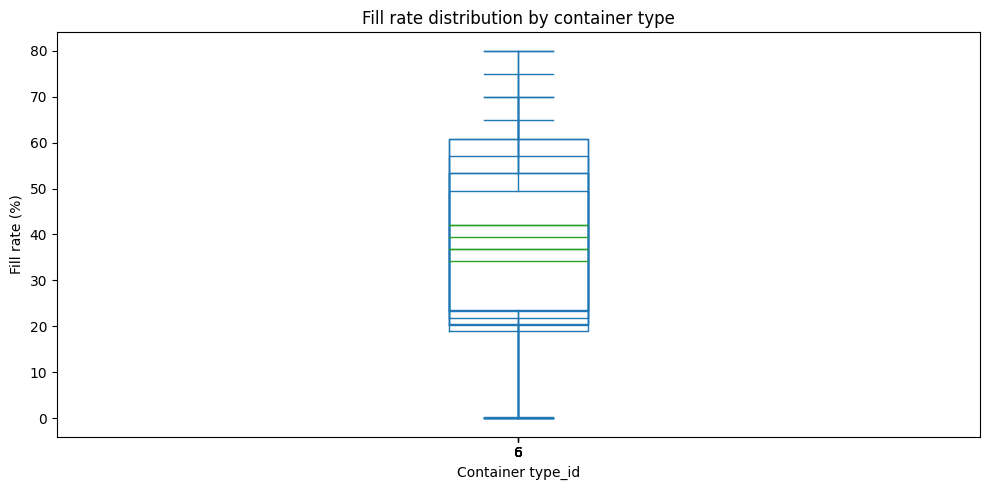

In [30]:
# Plot 1 — Fill rate distribution per container type
fig, ax = plt.subplots(figsize=(10, 5))
df_hist.groupby('type_id')['fill_rate'].plot.box(ax=ax, vert=True)
ax.set_title('Fill rate distribution by container type')
ax.set_xlabel('Container type_id')
ax.set_ylabel('Fill rate (%)')
plt.tight_layout()
plt.show()

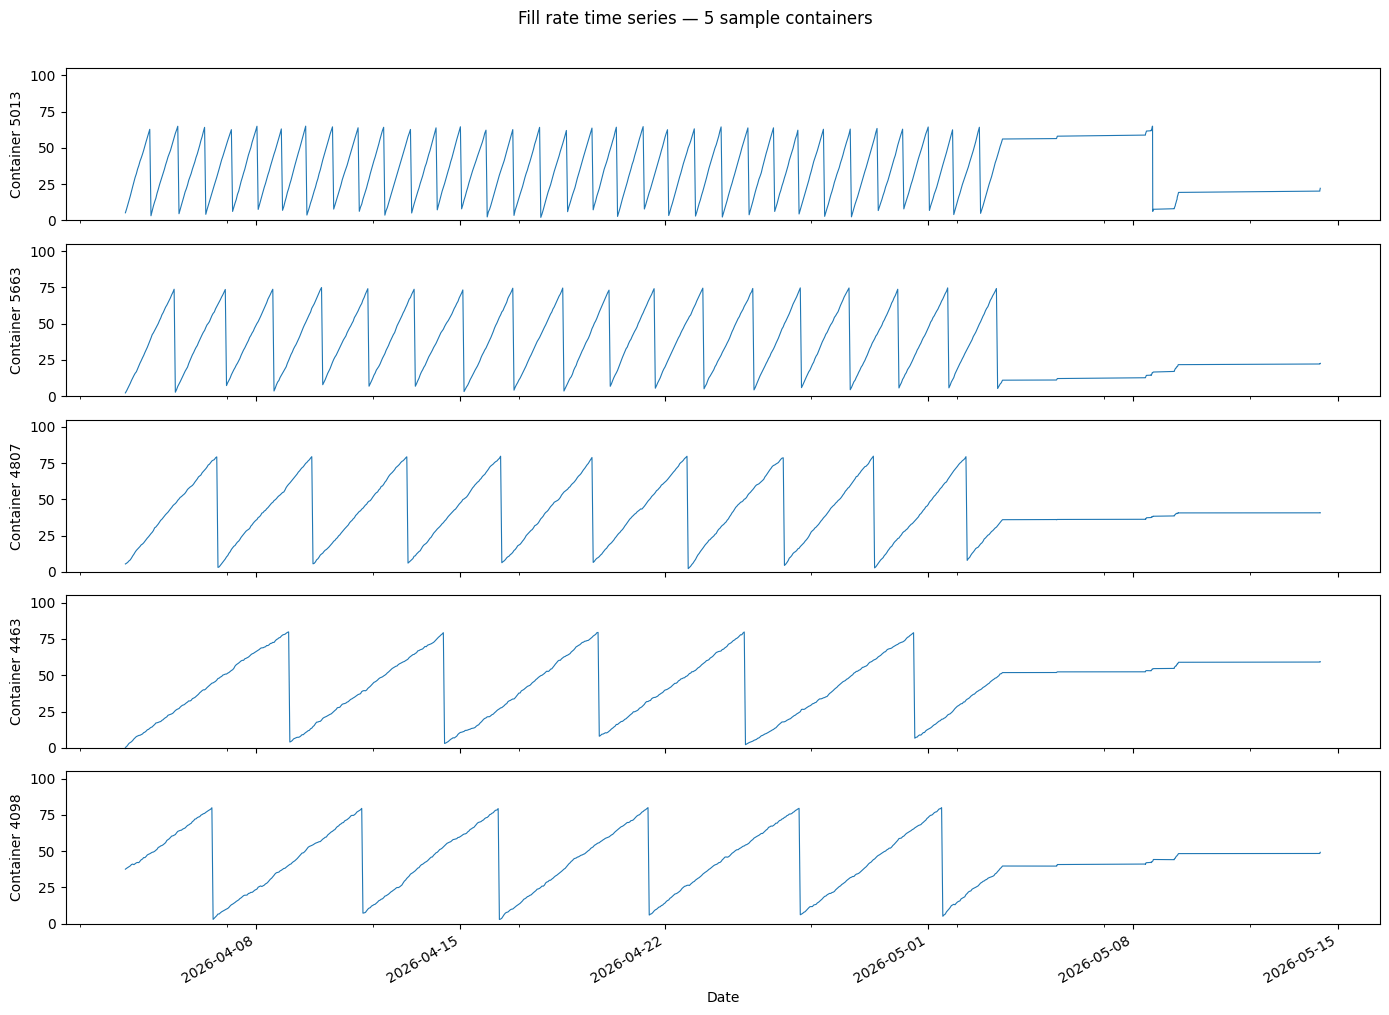

In [31]:
# Plot 2 — Time series for 5 sample containers
sample_ids = df_hist['container_id'].value_counts().head(5).index.tolist()
fig, axes = plt.subplots(len(sample_ids), 1, figsize=(14, 10), sharex=True)

for ax, cid in zip(axes, sample_ids):
    sub = df_hist[df_hist.container_id == cid].set_index('measured_at')
    sub['fill_rate'].plot(ax=ax, linewidth=0.8)
    ax.set_ylabel(f'Container {cid}')
    ax.set_ylim(0, 105)

axes[-1].set_xlabel('Date')
fig.suptitle('Fill rate time series — 5 sample containers', y=1.01)
plt.tight_layout()
plt.show()

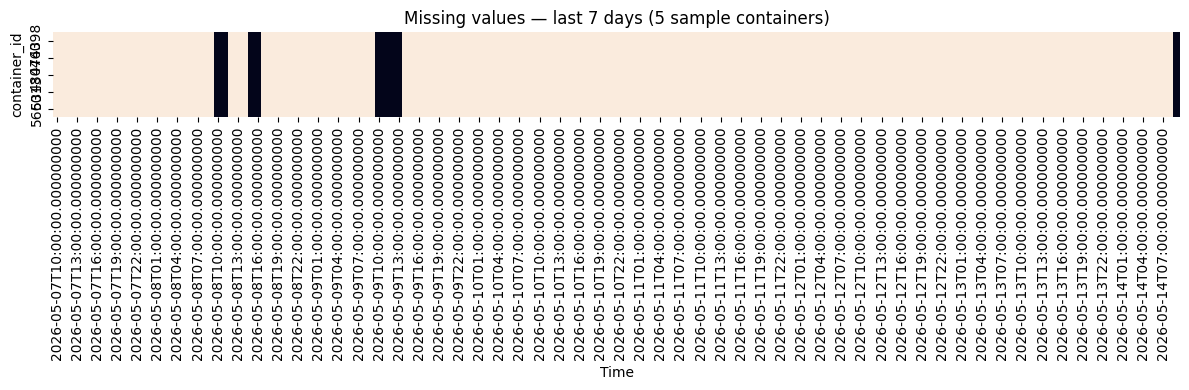

In [32]:
# Plot 3 — Missing value heatmap (sample of containers)
pivot_sample = (
    df_hist[df_hist.container_id.isin(sample_ids)]
    .pivot_table(index='measured_at', columns='container_id', values='fill_rate')
    .resample('1h').mean()
    .tail(168)  # last 7 days
)

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(pivot_sample.isnull().T, ax=ax, cbar=False, yticklabels=True)
ax.set_title('Missing values — last 7 days (5 sample containers)')
ax.set_xlabel('Time')
plt.tight_layout()
plt.show()

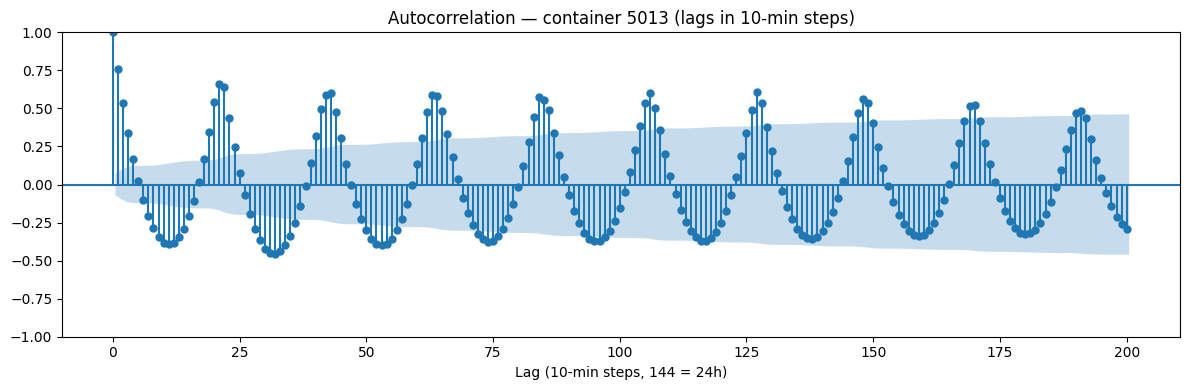

In [33]:
# Plot 4 — Autocorrelation (validates that lag features have signal)
one_container = df_hist[df_hist.container_id == sample_ids[0]].set_index('measured_at')

fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(one_container['fill_rate'].dropna(), lags=200, ax=ax, alpha=0.05)
ax.set_title(f'Autocorrelation — container {sample_ids[0]} (lags in 10-min steps)')
ax.set_xlabel('Lag (10-min steps, 144 = 24h)')
plt.tight_layout()
plt.show()

## 3. Feature Engineering

| Feature | Type | Description |
|---|---|---|
| `hour` | temporal | Hour of day (0–23) |
| `day_of_week` | temporal | Day of week (0=Mon, 6=Sun) |
| `day_of_month` | temporal | Day of month (1–31) |
| `is_weekend` | temporal | 1 if Saturday or Sunday |
| `is_peak_hour` | temporal | 1 if hour in {7,8,9,17,18,19} |
| `fill_rate_1h_ago` | lag | Fill rate ~1h before (shift 6 rows at 10-min cadence) |
| `fill_rate_24h_ago` | lag | Fill rate ~24h before (shift 144 rows) |
| `fill_rate_7d_ago` | lag | Fill rate ~7 days before (shift 1008 rows) |
| `fill_rate_24h_avg` | rolling | Trailing 24h mean (no future leakage via shift(1) first) |
| `fill_rate_7d_avg` | rolling | Trailing 7-day mean |
| `fill_rate_change_rate` | derivative | Δ fill_rate per 10-min step over the last 1h |
| `capacity_liters` | container | Physical capacity |
| `type_id` | container | Waste type category |
| `density_km2` | zone | Containers per km² in the zone |

In [34]:
df_hist = df_hist.sort_values(['container_id', 'measured_at']).reset_index(drop=True)
g = df_hist.groupby('container_id')['fill_rate']

# Compute actual sampling cadence so shift constants work regardless of seed-data interval
median_interval_min = (
    df_hist.groupby('container_id')['measured_at']
    .apply(lambda s: s.diff().dt.total_seconds().median() / 60)
    .median()
)
SHIFT_1H  = max(1, round(60            / median_interval_min))
SHIFT_24H = max(1, round(24 * 60       / median_interval_min))
SHIFT_7D  = max(1, round(7 * 24 * 60  / median_interval_min))

print(f'Median interval  : {median_interval_min:.1f} min')
print(f'Readings per day : {24*60/median_interval_min:.1f}')
print(f'Shifts — 1h={SHIFT_1H}, 24h={SHIFT_24H}, 7d={SHIFT_7D}')

# ── Temporal ────────────────────────────────────────────────────────────────
df_hist['hour']         = df_hist['measured_at'].dt.hour
df_hist['day_of_week']  = df_hist['measured_at'].dt.dayofweek
df_hist['day_of_month'] = df_hist['measured_at'].dt.day
df_hist['is_weekend']   = (df_hist['day_of_week'] >= 5).astype(int)
df_hist['is_peak_hour'] = df_hist['hour'].isin([7, 8, 9, 17, 18, 19]).astype(int)

# ── Lag features ─────────────────────────────────────────────────────────────
df_hist['fill_rate_1h_ago']  = g.shift(SHIFT_1H)
df_hist['fill_rate_24h_ago'] = g.shift(SHIFT_24H)
df_hist['fill_rate_7d_ago']  = g.shift(SHIFT_7D)

# ── Rolling averages (shift(1) first → no leakage of current reading) ────────
df_hist['fill_rate_24h_avg'] = (
    g.transform(lambda s: s.shift(1).rolling(SHIFT_24H, min_periods=max(2, SHIFT_24H // 10)).mean())
)
df_hist['fill_rate_7d_avg'] = (
    g.transform(lambda s: s.shift(1).rolling(SHIFT_7D, min_periods=max(2, SHIFT_7D // 10)).mean())
)
df_hist['fill_rate_change_rate'] = (
    g.transform(lambda s: (s - s.shift(SHIFT_1H)) / SHIFT_1H)
)

print('Lag/rolling features computed')

Median interval  : 60.0 min
Readings per day : 24.0
Shifts — 1h=1, 24h=24, 7d=168
Lag/rolling features computed


In [35]:
# Zone density join
df_hist = df_hist.merge(df_zones, left_on='zone_id', right_on='key_zone', how='left')
df_hist['density_km2'] = df_hist['density_km2'].fillna(0)

# Target: fill_rate 24h in the future
df_hist['target'] = g.shift(-SHIFT_24H)

print('Target and zone density added')

Target and zone density added


In [36]:
FEATURE_COLS = [
    'hour', 'day_of_week', 'day_of_month', 'is_weekend', 'is_peak_hour',
    'fill_rate_1h_ago', 'fill_rate_24h_ago', 'fill_rate_7d_ago',
    'fill_rate_24h_avg', 'fill_rate_7d_avg', 'fill_rate_change_rate',
    'capacity_liters', 'type_id', 'density_km2',
]

# Diagnose NaN counts before dropping — helps understand data volume issues
nan_counts = df_hist[FEATURE_COLS + ['target']].isnull().sum()
print('=== NaN counts per feature (before dropna) ===')
print(nan_counts.to_string())
print(f'\nTotal rows before dropna : {len(df_hist):,}')

df_clean = df_hist[FEATURE_COLS + ['target', 'container_id', 'measured_at']].dropna()
rows_dropped = len(df_hist) - len(df_clean)
print(f'Rows dropped by dropna   : {rows_dropped:,}')
print(f'Rows remaining           : {len(df_clean):,}')

if len(df_clean) == 0:
    print()
    print('ERROR: no rows survived dropna.')
    print('Most likely cause: fill_history has < 7 days of data, so all')
    print('  fill_rate_7d_ago (shift 1008) and fill_rate_7d_avg values are NaN.')
    print()
    print('Check how many days of data are available:')
    print('  SELECT MIN(measured_at), MAX(measured_at),')
    print('         COUNT(*), COUNT(DISTINCT container_id)')
    print('  FROM fill_history;')
    print()
    print('You need at least 8 days (7d lag + 1d target window) per container.')
    raise ValueError('Empty training set — not enough fill_history data. See message above.')

print(f'\nFeatures     : {len(FEATURE_COLS)}')
print(f'Date range   : {df_clean.measured_at.min()} → {df_clean.measured_at.max()}')
print(f'Containers   : {df_clean.container_id.nunique():,}')
print(f'Target range : {df_clean.target.min():.1f} – {df_clean.target.max():.1f}')

assert len(FEATURE_COLS) >= 8, 'Need at least 8 features (ML1 validation criterion)'
df_clean.describe()

=== NaN counts per feature (before dropna) ===
hour                          0
day_of_week                   0
day_of_month                  0
is_weekend                    0
is_peak_hour                  0
fill_rate_1h_ago           4000
fill_rate_24h_ago         96000
fill_rate_7d_ago         672000
fill_rate_24h_avg          8000
fill_rate_7d_avg          64000
fill_rate_change_rate      4000
capacity_liters               0
type_id                       0
density_km2                   0
target                    96000

Total rows before dropna : 3,033,488
Rows dropped by dropna   : 768,000
Rows remaining           : 2,265,488

Features     : 14
Date range   : 2026-04-10 13:00:00 → 2026-05-09 10:10:00
Containers   : 4,000
Target range : 2.0 – 80.0


,hour,day_of_week,day_of_month,is_weekend,is_peak_hour,fill_rate_1h_ago,fill_rate_24h_ago,fill_rate_7d_ago,fill_rate_24h_avg,fill_rate_7d_avg,fill_rate_change_rate,capacity_liters,type_id,density_km2,target,container_id,measured_at
count,2.265488e+06,2.265488e+06,2.265488e+06,2.265488e+06,2.265488e+06,2.265488e+06,2.265488e+06,2.265488e+06,2.265488e+06,2.265488e+06,2.265488e+06,2.265488e+06,2.265488e+06,2.265488e+06,2.265488e+06,2.265488e+06,2265488
mean,1.155399e+01,3.122334e+00,1.709509e+01,2.897866e-01,2.443734e-01,3.872120e+01,3.872396e+01,3.861678e+01,3.872072e+01,3.873158e+01,1.495740e-03,1.132323e+03,3.503285e+00,3.940101e+02,3.873378e+01,5.988336e+03,2026-04-25 02:47:17.013657856
min,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,2.000000e+00,1.000000e-02,3.320833e+00,3.007446e+01,-7.797000e+01,5.000000e+02,1.000000e+00,1.667852e+02,2.000000e+00,4.001000e+03,2026-04-10 13:00:00
25%,6.000000e+00,1.000000e+00,9.000000e+00,0.000000e+00,0.000000e+00,2.128000e+01,2.128000e+01,2.133000e+01,3.250917e+01,3.633000e+01,1.000000e+00,7.500000e+02,2.000000e+00,3.265697e+02,2.129000e+01,4.989000e+03,2026-04-19 02:00:00
50%,1.200000e+01,3.000000e+00,1.900000e+01,0.000000e+00,0.000000e+00,3.851000e+01,3.851000e+01,3.838000e+01,3.675792e+01,3.807054e+01,1.610000e+00,1.000000e+03,4.000000e+00,4.131494e+02,3.852000e+01,5.977000e+03,2026-04-25 01:00:00
75%,1.700000e+01,5.000000e+00,2.500000e+01,1.000000e+00,0.000000e+00,5.576000e+01,5.577000e+01,5.549000e+01,4.381625e+01,4.133263e+01,2.380000e+00,1.500000e+03,5.000000e+00,4.439446e+02,5.575000e+01,6.988000e+03,2026-05-01 00:00:00
max,2.300000e+01,6.000000e+00,3.000000e+01,1.000000e+00,1.000000e+00,8.000000e+01,8.000000e+01,8.000000e+01,7.887500e+01,5.396571e+01,7.232000e+01,2.000000e+03,6.000000e+00,6.195973e+02,8.000000e+01,8.000000e+03,2026-05-09 10:10:00
std,6.825904e+00,1.948253e+00,8.880251e+00,4.536633e-01,4.297152e-01,2.032881e+01,2.033358e+01,2.022522e+01,1.078442e+01,3.349066e+00,1.074895e+01,5.368811e+02,1.729476e+00,1.482817e+02,2.031885e+01,1.154631e+03,NaN


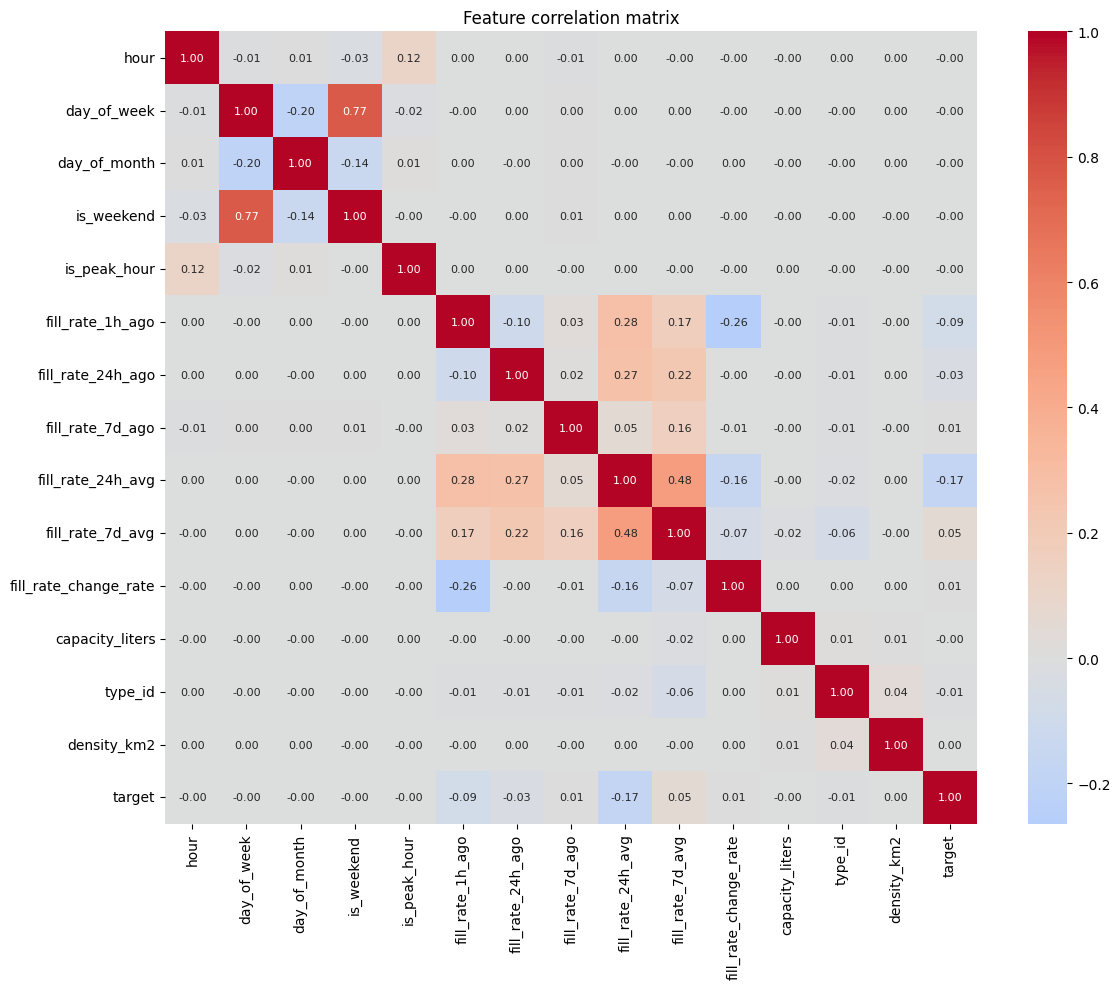

In [37]:
# Feature correlation heatmap (optional, informational)
fig, ax = plt.subplots(figsize=(12, 10))
corr = df_clean[FEATURE_COLS + ['target']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax,
            annot_kws={'size': 8})
ax.set_title('Feature correlation matrix')
plt.tight_layout()
plt.show()

In [38]:
os.makedirs('data', exist_ok=True)
df_clean.to_parquet('data/training_features.parquet', index=False)
print(f'Saved: data/training_features.parquet ({len(df_clean):,} rows, {len(FEATURE_COLS)} features)')

Saved: data/training_features.parquet (2,265,488 rows, 14 features)


In [39]:
conn.close()
print('Done — proceed to 02_training.ipynb')

Done — proceed to 02_training.ipynb
